<a href="https://colab.research.google.com/github/dogyeong06/2026_tues_bigatacomputing_class/blob/main/%EC%A4%91%EA%B0%84%EA%B3%A0%EC%82%AC_%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D_%EA%B3%BC%EC%A0%9C_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  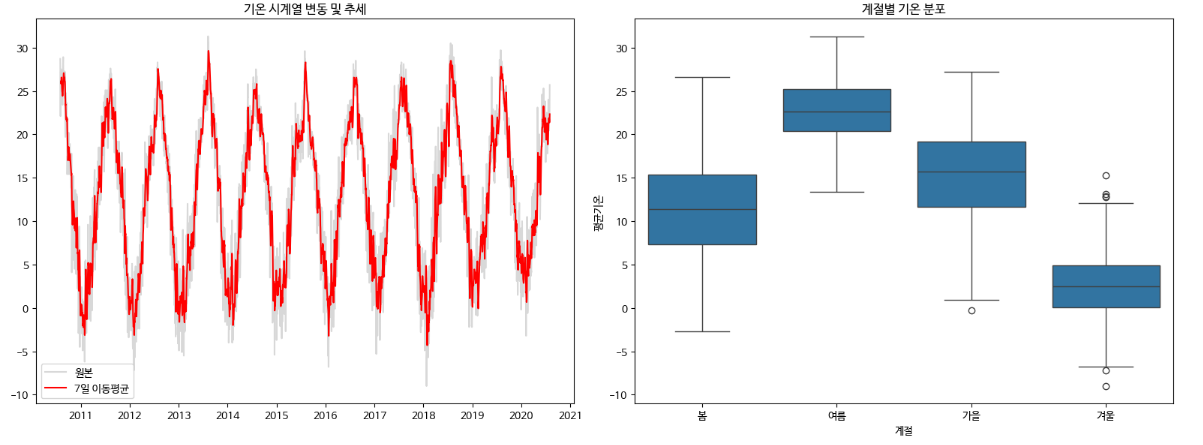

  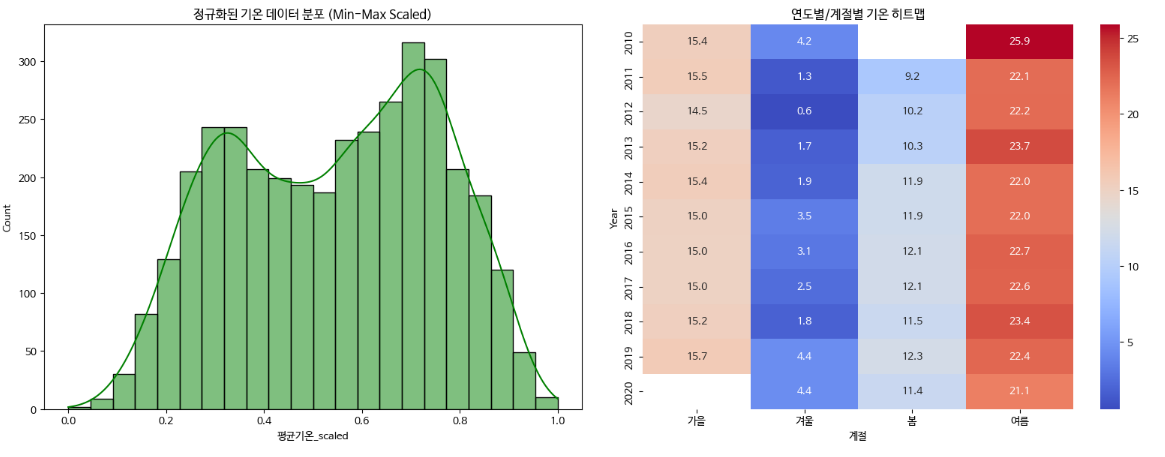



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


/tmp/ipykernel_538/4153417687.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  season_stats = df.groupby('계절')['평균기온'].describe().reset_index()
/tmp/ipykernel_538/4153417687.py:38: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  yearly_seasonal_pivot = pd.pivot_table(df, values='평균기온', index='연도', columns='계절', aggfunc='mean')


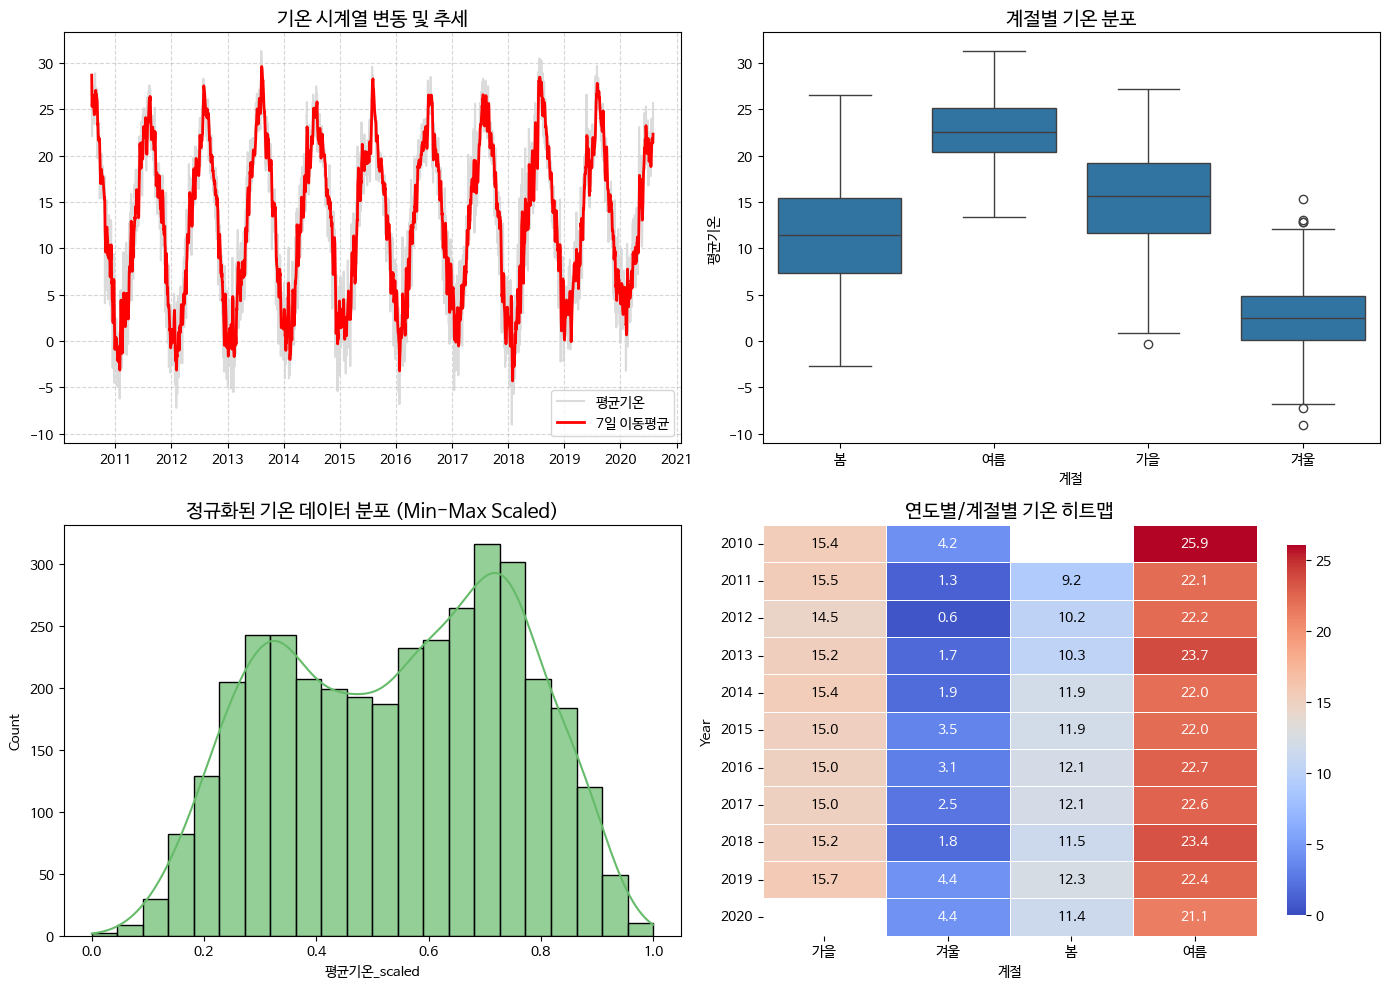

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.font_manager as fm
import pandas as pd
import seaborn as sns

def setup_korean_font():
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    if not os.path.exists(font_path):
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')
    fm.fontManager.addfont(font_path)
    plt.rc('font', family='NanumBarunGothic')
    plt.rcParams['axes.unicode_minus'] = False

def load_data(url):
    return pd.read_csv(url, encoding='cp949')

def min_max_scaling(df, column):
    min_val = df[column].min()
    max_val = df[column].max()
    df[f'{column}_정규화'] = (df[column] - min_val) / (max_val - min_val)
    return df

def process_time_series(df):
    df['일시'] = pd.to_datetime(df['일시'])
    df['연도'] = df['일시'].dt.year
    df['월'] = df['일시'].dt.month
    month_to_season = {12: '겨울', 1: '겨울', 2: '겨울', 3: '봄', 4: '봄', 5: '봄', 6: '여름', 7: '여름', 8: '여름', 9: '가을', 10: '가을', 11: '가을'}
    df['계절'] = df['월'].map(month_to_season)
    df['계절'] = pd.Categorical(df['계절'], categories=['봄', '여름', '가을', '겨울'], ordered=True)
    df.set_index('일시', inplace=True)
    df['평균기온_7일_이동평균'] = df['평균기온'].rolling(window=7, min_periods=1).mean()
    return df

def restructure_data(df):
    season_stats = df.groupby('계절')['평균기온'].describe().reset_index()
    yearly_seasonal_pivot = pd.pivot_table(df, values='평균기온', index='연도', columns='계절', aggfunc='mean')
    return season_stats, yearly_seasonal_pivot

def plot_charts(df, yearly_seasonal_pivot):
    plt.rcParams['font.size'] = 10
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].plot(df.index, df['평균기온'], color='lightgray', alpha=0.8, label='평균기온')
    axes[0, 0].plot(df.index, df['평균기온_7일_이동평균'], color='red', linewidth=2, label='7일 이동평균')
    axes[0, 0].set_title('기온 시계열 변동 및 추세', fontweight='bold', fontsize=14)
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(True, linestyle='--', alpha=0.5)

    sns.boxplot(data=df, x='계절', y='평균기온', ax=axes[0, 1])
    axes[0, 1].set_title('계절별 기온 분포', fontweight='bold', fontsize=14)
    axes[0, 1].set_xlabel('계절', fontsize=10)
    axes[0, 1].set_ylabel('평균기온', fontsize=10)

    data = df['평균기온_정규화'].dropna()
    sns.histplot(data, bins=22, kde=True, line_kws={'color': 'green', 'linewidth': 1.5}, ax=axes[1, 0], color='#66bb6a', edgecolor='black', alpha=0.7)
    axes[1, 0].set_title('정규화된 기온 데이터 분포 (Min-Max Scaled)', fontweight='bold', fontsize=14)
    axes[1, 0].set_xlabel('평균기온_scaled', fontsize=10)
    axes[1, 0].set_ylabel('Count', fontsize=10)

    pivot = yearly_seasonal_pivot[['가을', '겨울', '봄', '여름']]
    heatmap = sns.heatmap(pivot, cmap='coolwarm', annot=True, fmt=".1f", linewidths=0.5, vmin=0, vmax=26, cbar_kws={"shrink": 0.9}, ax=axes[1, 1], annot_kws={"size": 10})
    for text in heatmap.texts:
        col_index = int(text.get_position()[0] - 0.5)
        if col_index in [1, 3]:
            text.set_color('white')
        else:
            text.set_color('black')
    axes[1, 1].set_title('연도별/계절별 기온 히트맵', fontweight='bold', fontsize=14)
    axes[1, 1].set_xlabel('계절', fontsize=10)
    axes[1, 1].set_ylabel('Year', fontsize=10)

    for ax in axes.flat:
        ax.tick_params(axis='both', labelsize=10)

    plt.tight_layout()
    plt.show()

def save_to_excel(df, season_stats, yearly_seasonal_pivot):
    df_reset = df.reset_index()
    with pd.ExcelWriter("weather_analysis_report.xlsx") as writer:
        df_reset.to_excel(writer, sheet_name='전처리_데이터', index=False)
        season_stats.to_excel(writer, sheet_name='계절별_기온통계', index=False)
        yearly_seasonal_pivot.to_excel(writer, sheet_name='연도별_계절별_피벗')

def main():
    setup_korean_font()
    url = "https://github.com/dongupak/DataML/raw/main/csv/weather.csv"
    df = load_data(url)
    df = min_max_scaling(df, '평균기온')
    df = process_time_series(df)
    season_stats, yearly_seasonal_pivot = restructure_data(df)
    plot_charts(df, yearly_seasonal_pivot)
    save_to_excel(df, season_stats, yearly_seasonal_pivot)

if __name__ == "__main__":
    main()